In [6]:
import sys
print(sys.executable)

# Use --user to install in your user directory (avoids Access Denied issues)
!"{sys.executable}" -m pip install --user tensorflow keras opencv-python tqdm numpy scikit-learn matplotlib seaborn

C:\ProgramData\anaconda3\python.exe


In [7]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2 # Using MobileNetV2 for feature extraction
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence # Import Sequence

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

# Define your data paths
# IMPORTANT: Replace these with the actual paths on your system
real_path = r"F:\MAJOR-PROJECT\Data\Preprocessed\Real"
fake_path = r"F:\MAJOR-PROJECT\Data\Preprocessed\Fake"

# Ensure paths exist
if not os.path.exists(real_path):
    print(f"Error: Real video path not found at {real_path}")
if not os.path.exists(fake_path):
    print(f"Error: Fake video path not found at {fake_path}")

# Frame size for CNN input
FRAME_SIZE = (224, 224) # MobileNetV2 expects (224, 224)
NUM_FRAMES = 20 # Number of frames to extract per video

All libraries imported successfully!


In [8]:
def extract_features_from_video(video_path, num_frames=NUM_FRAMES, frame_size=FRAME_SIZE):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        # print(f"Error: Could not open video {video_path}") # Suppress frequent error messages during batching
        return np.zeros((num_frames, frame_size[0], frame_size[1], 3), dtype=np.float32)

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < num_frames:
        frame_indices = np.arange(total_frames)
    else:
        frame_indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    count = 0
    current_frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if current_frame_idx in frame_indices:
            frame = cv2.resize(frame, frame_size)
            frame = frame / 255.0 # Normalize pixel values to [0, 1]
            frames.append(frame.astype(np.float32))
            count += 1
            if count == num_frames:
                break
        current_frame_idx += 1

    cap.release()

    while len(frames) < num_frames:
        frames.append(np.zeros((frame_size[0], frame_size[1], 3), dtype=np.float32))

    return np.array(frames, dtype=np.float32)

print("Video feature extraction function defined.")

Video feature extraction function defined.


In [9]:
# Gather all video paths and labels
real_videos = [os.path.join(real_path, f) for f in os.listdir(real_path) if f.endswith(('.mp4', '.avi', '.mov', '.mkv'))]
fake_videos = [os.path.join(fake_path, f) for f in os.listdir(fake_path) if f.endswith(('.mp4', '.avi', '.mov', '.mkv'))]

video_paths = real_videos + fake_videos
labels = [0] * len(real_videos) + [1] * len(fake_videos)

print(f"Total videos identified: {len(video_paths)}")
print(f"Real videos: {len(real_videos)}, Fake videos: {len(fake_videos)}")

# Split data into training and testing sets (using paths, not actual data)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    video_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train samples: {len(train_paths)}, Test samples: {len(test_paths)}")

Total videos identified: 726
Real videos: 363, Fake videos: 363
Train samples: 580, Test samples: 146


In [10]:
class VideoFrameGenerator(Sequence):
    def __init__(self, video_paths, labels, batch_size, num_frames=NUM_FRAMES, frame_size=FRAME_SIZE, shuffle=True):
        self.video_paths = video_paths
        self.labels = np.array(labels) # Ensure labels are numpy array
        self.batch_size = batch_size
        self.num_frames = num_frames
        self.frame_size = frame_size
        self.shuffle = shuffle
        self.on_epoch_end() # Initialize indices

    def __len__(self):
        # Number of batches per epoch
        return int(np.floor(len(self.video_paths) / self.batch_size))

    def __getitem__(self, index):
        # Generate one batch of data
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_video_paths = [self.video_paths[k] for k in indexes]
        batch_labels = self.labels[indexes]

        X_batch = np.empty((self.batch_size, self.num_frames, self.frame_size[0], self.frame_size[1], 3), dtype=np.float32)
        y_batch = np.empty((self.batch_size), dtype=np.int32)

        for i, path in enumerate(batch_video_paths):
            frames = extract_features_from_video(path, self.num_frames, self.frame_size)
            X_batch[i,] = frames
            y_batch[i] = batch_labels[i]

        return X_batch, y_batch

    def on_epoch_end(self):
        # Updates indexes after each epoch
        self.indexes = np.arange(len(self.video_paths))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

print("VideoFrameGenerator class defined.")

# Create data generators
BATCH_SIZE = 8 # Define your batch size here
train_generator = VideoFrameGenerator(train_paths, train_labels, batch_size=BATCH_SIZE)
test_generator = VideoFrameGenerator(test_paths, test_labels, batch_size=BATCH_SIZE, shuffle=False) # No need to shuffle test data

print(f"Train generator created with {len(train_generator)} batches.")
print(f"Test generator created with {len(test_generator)} batches.")

VideoFrameGenerator class defined.
Train generator created with 72 batches.
Test generator created with 18 batches.


In [11]:
def build_cnn_lstm_model(input_shape, num_frames):
    cnn_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=FRAME_SIZE + (3,))
    for layer in cnn_base.layers:
        layer.trainable = False

    model = Sequential([
        Input(shape=input_shape),
        TimeDistributed(cnn_base),
        TimeDistributed(GlobalAveragePooling2D()),
        LSTM(128, return_sequences=False),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Input shape for the model: (NUM_FRAMES, FRAME_SIZE[0], FRAME_SIZE[1], 3)
model = build_cnn_lstm_model((NUM_FRAMES, FRAME_SIZE[0], FRAME_SIZE[1], 3), NUM_FRAMES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ (None, 20, 7, 7, 1280)      │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 20, 1280)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │         721,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,987,713 (11.40 MB)

 Trainable params: 729,729 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
# Callbacks for better training
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

print("Starting model training using data generators...")
history = model.fit(
    train_generator,
    epochs=50, # Max epochs, early stopping will manage
    validation_data=test_generator, # Use test_generator for validation
    callbacks=[early_stopping, reduce_lr],
    # Removed 'workers' and 'use_multiprocessing'
    # workers=os.cpu_count(),
    # use_multiprocessing=True
)
print("Model training finished.")

Starting model training using data generators...


C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 702s 7s/step - accuracy: 0.5851 - loss: 0.6735 - val_accuracy: 0.7222 - val_loss: 0.6280 - learning_rate: 1.0000e-04
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 434s 6s/step - accuracy: 0.7014 - loss: 0.5892 - val_accuracy: 0.8542 - val_loss: 0.5157 - learning_rate: 1.0000e-04
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 408s 6s/step - accuracy: 0.7969 - loss: 0.4958 - val_accuracy: 0.8819 - val_loss: 0.3848 - learning_rate: 1.0000e-04
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 929s 13s/step - accuracy: 0.8160 - loss: 0.4056 - val_accuracy: 0.9306 - val_loss: 0.2792 - learning_rate: 1.0000e-04
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 313s 4s/step - accuracy: 0.8906 - loss: 0.3057 - val_accuracy: 0.9167 - val_loss: 0.2622 - learning_rate: 1.0000e-04
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 294s 4s/step - accuracy: 0.8819 - loss: 0.2973 - val_accuracy: 0.9444 - val_loss: 0.2280 - learning_rate: 1.0000e-04
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 296s 4s/step - accuracy: 0.9149

Evaluating model performance on test set...
18/18 ━━━━━━━━━━━━━━━━━━━━ 83s 5s/step - accuracy: 0.9583 - loss: 0.1797 
✅ Test Loss: 0.1797
✅ Test Accuracy: 95.83%
Generating predictions on the test set for metrics...


100%|██████████████████████████████████████████████████████████████████████████████████| 18/18 [02:53<00:00,  9.65s/it]



--- Classification Report ---
              precision    recall  f1-score   support

        Real       0.97      0.95      0.96        73
        Fake       0.95      0.97      0.96        71

    accuracy                           0.96       144
   macro avg       0.96      0.96      0.96       144
weighted avg       0.96      0.96      0.96       144


--- Confusion Matrix ---


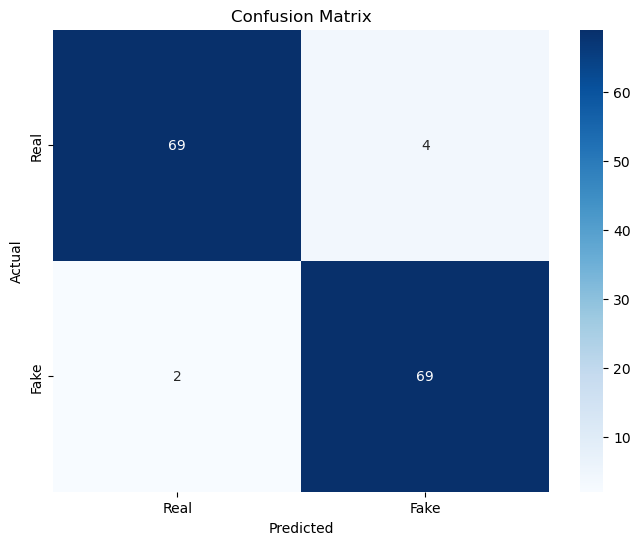

Confusion Matrix plot generated.


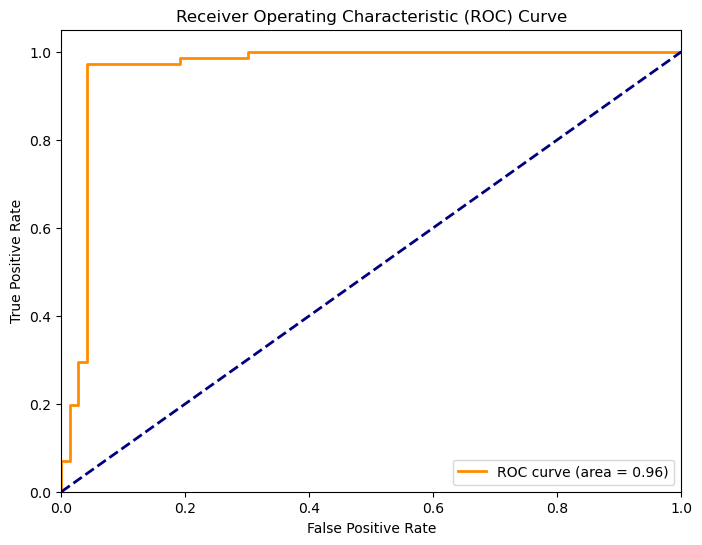

ROC Curve plot generated.


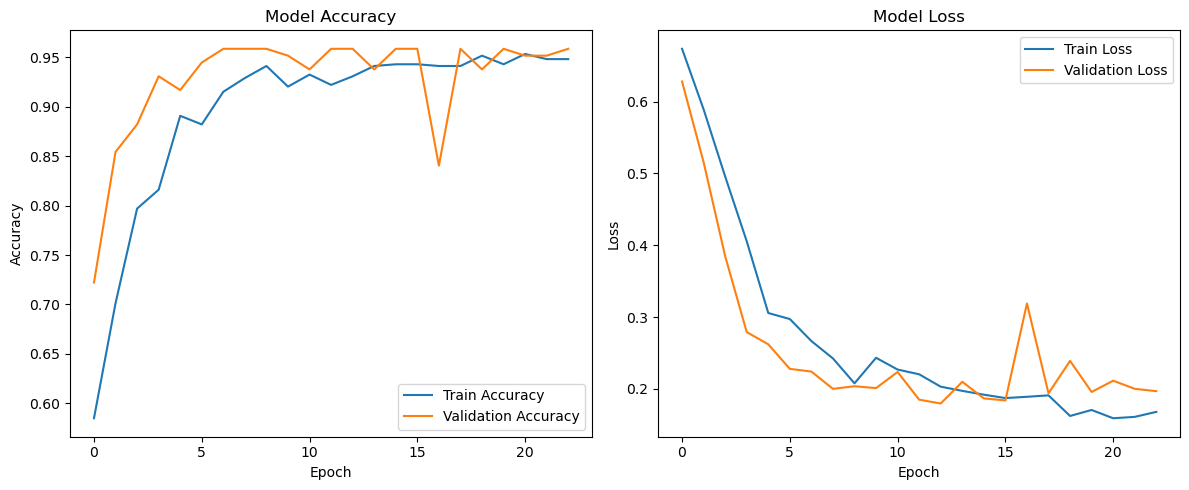

Training history plots generated.


In [14]:
print("Evaluating model performance on test set...")
# Use test_generator directly for evaluation. Removed multiprocessing arguments here too.
loss, accuracy = model.evaluate(test_generator) # Removed workers and use_multiprocessing
print(f"✅ Test Loss: {loss:.4f}")
print(f"✅ Test Accuracy: {accuracy*100:.2f}%")

# Predict probabilities on the test set using the generator
y_pred_proba_list = []
y_true_list = []

print("Generating predictions on the test set for metrics...")
for i in tqdm(range(len(test_generator))):
    X_batch, y_batch = test_generator[i]
    y_pred_proba_batch = model.predict(X_batch, verbose=0).ravel() # Added verbose=0 to suppress per-batch prediction logs
    y_pred_proba_list.extend(y_pred_proba_batch)
    y_true_list.extend(y_batch)

y_pred_proba = np.array(y_pred_proba_list)
y_true = np.array(y_true_list)
y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

# Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print("Confusion Matrix plot generated.")

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
print("ROC Curve plot generated.")

# Plot training history (from the history object returned by model.fit)
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
print("Training history plots generated.")

In [15]:
def predict_deepfake(video_path, model, num_frames=NUM_FRAMES, frame_size=FRAME_SIZE):
    if not os.path.exists(video_path):
        return "Error: Video file not found."

    print(f"\nAnalyzing video: {video_path}")
    frames = extract_features_from_video(video_path, num_frames, frame_size)

    if frames.shape[0] != num_frames:
        return "Error: Could not extract enough frames from the video. Check video file integrity or duration."

    # The model expects a batch, so add an extra dimension
    frames = np.expand_dims(frames, axis=0) # Shape becomes (1, num_frames, height, width, channels)

    prediction = model.predict(frames, verbose=0)[0][0] # Get the single probability value
    
    threshold = 0.5
    if prediction >= threshold:
        result = "FAKE"
        confidence = prediction * 100
    else:
        result = "REAL"
        confidence = (1 - prediction) * 100

    return f"The video is predicted to be: {result} with {confidence:.2f}% confidence."

print("\n--- Example Prediction Usage ---")
print("To predict on a new video, uncomment the 'example_video_path' line and the following two lines.")
print(r"C:\Users\LENOVO\OneDrive\Pictures\Saved Pictures\01_02__outside_talking_still_laughing__YVGY8LOK.mp4")

# For demonstration, let's pick a random video from the test set
if len(test_paths) > 0:
    random_idx = np.random.randint(0, len(test_paths))
    random_test_video_path = test_paths[random_idx]
    true_label = "REAL" if test_labels[random_idx] == 0 else "FAKE"
    
    print(f"\nDemonstrating prediction on a random video from the test set: {random_test_video_path}")
    print(f"True label for this video: {true_label}")
    
    prediction_result = predict_deepfake(random_test_video_path, model)
    print(prediction_result)
else:
    print("No test videos available for demonstration.")


--- Example Prediction Usage ---
To predict on a new video, uncomment the 'example_video_path' line and the following two lines.
C:\Users\LENOVO\OneDrive\Pictures\Saved Pictures\01_02__outside_talking_still_laughing__YVGY8LOK.mp4

Demonstrating prediction on a random video from the test set: F:\MAJOR-PROJECT\Data\Preprocessed\Fake\02_15__outside_talking_pan_laughing__SB6PMCO0_preprocessed.mp4
True label for this video: FAKE

Analyzing video: F:\MAJOR-PROJECT\Data\Preprocessed\Fake\02_15__outside_talking_pan_laughing__SB6PMCO0_preprocessed.mp4
The video is predicted to be: FAKE with 96.54% confidence.


In [16]:
def predict_deepfake(video_path, model, num_frames=NUM_FRAMES, frame_size=FRAME_SIZE):
    if not os.path.exists(video_path):
        return "Error: Video file not found."

    print(f"\nAnalyzing video: {video_path}")
    frames = extract_features_from_video(video_path, num_frames, frame_size)

    if frames.shape[0] != num_frames:
        return "Error: Could not extract enough frames from the video. Check video file integrity or duration."

    # The model expects a batch, so add an extra dimension
    frames = np.expand_dims(frames, axis=0) # Shape becomes (1, num_frames, height, width, channels)

    prediction = model.predict(frames, verbose=0)[0][0] # Get the single probability value
    
    threshold = 0.5
    if prediction >= threshold:
        result = "FAKE"
        confidence = prediction * 100
    else:
        result = "REAL"
        confidence = (1 - prediction) * 100

    return f"The video is predicted to be: {result} with {confidence:.2f}% confidence."

print("\n--- Example Prediction Usage ---")
print("To predict on a new video, uncomment the 'example_video_path' line and the following two lines.")
print(r"F:\MAJOR-PROJECT\Video\DATA\test_videos\0icpg7s3wk.mp4")

# For demonstration, let's pick a random video from the test set
if len(test_paths) > 0:
    random_idx = np.random.randint(0, len(test_paths))
    random_test_video_path = test_paths[random_idx]
    true_label = "REAL" if test_labels[random_idx] == 0 else "FAKE"
    
    print(f"\nDemonstrating prediction on a random video from the test set: {random_test_video_path}")
    print(f"True label for this video: {true_label}")
    
    prediction_result = predict_deepfake(random_test_video_path, model)
    print(prediction_result)
else:
    print("No test videos available for demonstration.")


--- Example Prediction Usage ---
To predict on a new video, uncomment the 'example_video_path' line and the following two lines.
F:\MAJOR-PROJECT\Video\DATA\test_videos\0icpg7s3wk.mp4

Demonstrating prediction on a random video from the test set: F:\MAJOR-PROJECT\Data\Preprocessed\Real\21__talking_against_wall_preprocessed.mp4
True label for this video: REAL

Analyzing video: F:\MAJOR-PROJECT\Data\Preprocessed\Real\21__talking_against_wall_preprocessed.mp4
The video is predicted to be: REAL with 99.52% confidence.
